In [17]:
import pocam_light
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import hephaistos as hp
#hp.selectDevice(0)
import hephaistos.pipeline as pl
from theia.volume import Attenuating
import theia
import theia.units as u
from pathlib import Path
from theia.compiler import addIncludeDir
import Ice_layers
import LayerMediumModel 
addIncludeDir(Path("shader"))
from theia.ray import UnpolarizedRay
from theia.target import SphereTargetGuide


In [18]:
stack = Ice_layers.LayerStack("icemodel.dat")

## Parameter für sphereLight

In [19]:
light_position = (46.9072, -56.5889, -385.93)
wavelength = theia.light.ConstWavelengthSource(405.0 * u.nm)

medium_idx = stack.get_medium_index(light_position[2])
print(stack.material_store.media["Layer_124"])

124


### Target

In [20]:
targetGuide = SphereTargetGuide(
    position=(31.25, -72.93, -383.40) * u.m,
    radius=0.5 * u.m,
)

## Paramter für SceneForwardTracer

In [30]:
batchSize = 1000000
ray = UnpolarizedRay()
sphereLight = pocam_light.PocamLightSource(
    wavelength,
    mediumIdx=medium_idx,
)
response = theia.response.HistogramHitResponse(
    theia.response.UniformValueResponse(),
    binCount=200,
    binSize= 3.0 * u.ns,
    t0 = 90 * u.ns
)
rng = theia.random.PhiloxRNG(key=0xABBA)
scene = stack.scene

stats = theia.trace.EventStatisticCallback()

In [31]:
sphereTracer = theia.trace.SceneForwardTracer(
    batchSize,
    ray,
    sphereLight,
    response,
    rng,
    scene,
    targetId=1,
    targetGuide=targetGuide,
    maxPathLength=1000,
    callback = stats
    #DisableTargetSampling = False
)


In [32]:
tasks = [
    ("sphere", {
        "lightSource__budget": 1e9,
        "lightSource__position": (
            46.9072,
            -56.5889,
            -385.93,
        ) * u.m,
    }),
]

### Tests 

In [33]:
print(len(stack.instances))#es sollen 172 sein (1 Detektor und 171 Eisschichten)

172


In [34]:
print(stack.materials[-1].name) # DOM

DOM


In [35]:
print(stack.instances[-1].material)

DOM


## Submit Work

In [36]:
spherePipeline = pl.Pipeline(sphereTracer.collectStages())

hists = []
def process(config: int, batch: int, args: None) -> None:
    hists.append(response.result(config).copy())

pipelineMap = {
    "sphere": spherePipeline,
}
scheduler = pl.PipelineScheduler(pipelineMap, processFn=process)


scheduler.schedule(tasks)
scheduler.wait()

In [37]:
t = (
    np.arange(response.binCount) * response.binSize + response.t0
) / u.ns

sphereSignal = np.mean(hists[:5], 0)
sphereSignalNorm = sphereSignal / (
    np.sum(sphereSignal) * response.binSize / u.ns
)
print(np.sum(sphereSignal))
print(stats)

84996.35895675082
 absorbed: 89
  created: 1,000,000
  decayed: 0
 detected: 0
    error: 0
      hit: 0
     lost: 0
  maxIter: 0
 mismatch: 999,911
   missed: 0
scattered: 5,982,248
   volume: 790,800


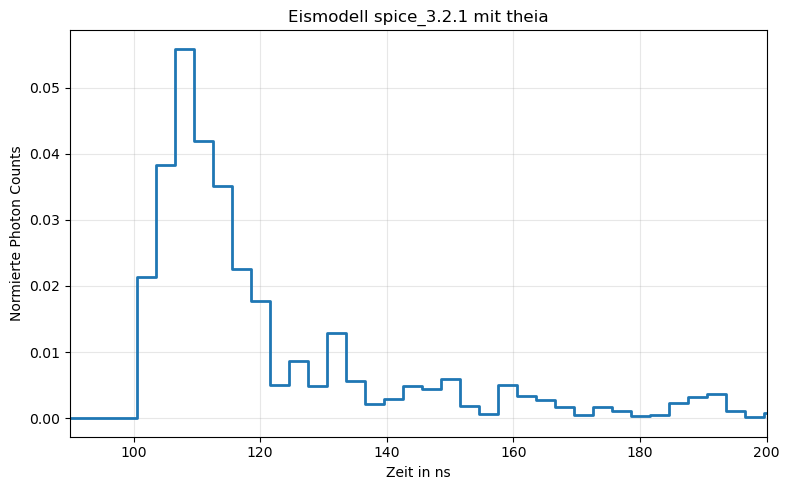

In [38]:
plt.figure(figsize=(8,5))
plt.step(
    t,
    sphereSignalNorm,
    where="mid",
    linewidth=2,
    label="Spherical source"
)

plt.xlabel("Zeit in ns")
plt.ylabel("Normierte Photon Counts")
plt.title(r"Eismodell spice_3.2.1 mit theia")
#plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlim(90,200)

plt.tight_layout()
plt.savefig("1_withsc_withlayers.pdf")


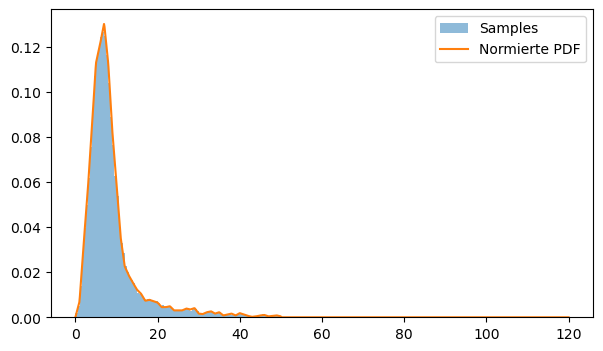

In [27]:
# Test, ob NumericalInversePolynomial die richtige Wahrscheinlichkeitsverteilung samplet

from scipy.stats.sampling import NumericalInversePolynomial
import numpy as np
import matplotlib.pyplot as plt
from pocam_light import _the_pulse

class Dist:
    def pdf(self, x):
        return _the_pulse(x, 15.0) 
                                   #NumericalInversePolynomial() erwartet nämlich ein Objekt das von Dist() erzeugt
                                   #wird und eine Methode pdf(x) besitzt

inv_cdf = NumericalInversePolynomial(
    Dist(),
    domain=(0.0, 120.0),              #erwartet ein Objekt mit Mehode
)
samples = inv_cdf.rvs(size=100000)

plt.figure(figsize=(7,4))

x = np.linspace(0,120,1000)

pdf = _the_pulse(x, 15)
pdf /= np.trapezoid(pdf, x)   # Nomirern!!

plt.hist(samples, bins=100, density=True, alpha=0.5, label="Samples") # density= TRue zur Normierung
plt.plot(x, pdf, label="Normierte PDF")

plt.legend()
plt.show()

In [ ]:
#Test, ob die Pocam-Lightsource funktioniert und Vergl. der Zeiten mit den zeiten der pulse_fkt

import pytest

import numpy as np
import scipy.integrate as integrate
import scipy.stats as stats

import hephaistos as hp
from hephaistos.pipeline import Pipeline, PipelineScheduler, runPipeline
from hephaistos.queue import dumpQueue
from ctypes import Structure, c_float

import theia.light
import theia.units as u
from theia.compiler import compileShader
from theia.material import MaterialStore, PureWaterModel, VACUUM_IDX
from theia.random import PhiloxRNG
from theia.ray import UnpolarizedRay
from theia.testing import BackwardLightSampler

N = 32 * 256
position = (14.0, -2.0, 3.0) * u.m
budget = 12.0

ray = UnpolarizedRay()
philox = PhiloxRNG(key=0xC0110FFC0FFEE)

photons = theia.light.ConstWavelengthSource(
    wavelength=100.0 * u.nm
)

light = pocam_light.PocamLightSource(
    photons,
    position=position,
    budget=budget,
    mediumIdx=VACUUM_IDX,
)

sampler = theia.light.LightSampler(
    N,
    light,
    ray,
    rng=philox,
)

runPipeline(sampler.collectStages())

result = sampler.queue.view(0)

plt.figure(figsize=(8,5))
plt.hist(times, bins=100, density=True, alpha=0.5, label="PocamLightSource")

x = np.linspace(0,120,1000)
pdf = _the_pulse(x,15)
pdf /= np.trapezoid(pdf, x)

plt.plot(x, pdf, lw=2, label=" _the_pulse (normiet)")

plt.legend()
plt.show()


In [ ]:
!git --version